# Hicks-Ray CSTR: the infinite-horizon terminal segment

Implements [Dinh et al. (2025)](https://doi.org/10.1016/j.jprocont.2025.103565),
"Nonlinear model predictive control with an infinite horizon approximation,"
*Journal of Process Control* 155, 103565.

Finite-horizon NMPC buys stability with terminal costs and terminal regions
that are hard to construct for nonlinear systems. The terminal segment takes
the alternative route: append the tail of the horizon to t = infinity,
compressed onto [0, 1) by the time transformation `tau = tanh(gamma*(t - tN))`,
and solve it inside the same NLP. The ingredients:

- **Dilated dynamics.** On the segment the dynamics carry the factor
  `gamma*(1 - tau^2)`, the transformation's Jacobian (eq. 25).
- **Gauss-Legendre collocation.** No collocation equation may sit at the
  singular endpoint `tau = 1`, so the segment discretizes with interior
  Legendre points, and endpoint values come from the polynomial extrapolation
  (eq. 26c).
- **Endpoint pin.** The segment endpoint `z(tau=1)`, the paper's evaluated
  endpoint (the Legendre extrapolation, eq. 26c), is pinned to the steady
  state by default (`terminal='soft'`: the eq. 36 endpoint relaxed by an L1
  penalty `mu`, so `z(tau=1) + eps_up - eps_lo == z_s` with `mu*(eps_up +
  eps_lo)` in the objective). `terminal='none'` drops the pin, leaving the singular tail
  weights to drive the tail to settle on their own. A pin reads the declared
  steady-state targets. On this settled CSTR the tail reaches the setpoint
  either way; the pin is what stabilizes open-loop-unstable plants, where the
  cost alone does not pin the growing modes.
- **The true tail cost.** The stage cost integrates through the segment, so
  the terminal cost is the infinite-horizon cost-to-go itself, the paper's
  `(beta/dt)*phi_f`, overestimated by a safety factor `beta > 1` (Thm. 8).
- **The gamma rule.** `gamma` puts the segment's first collocation point one
  sampling time past the junction (Fig. 2), so time resolution is continuous
  across it.

Four takes on the same problem follow: model 1, the packaged path
(`drto.infinite_horizon`); model 2, the N = 50 finite-horizon baseline it is
measured against; model 3, the segment built by hand with the quadrature
state `phi`; and model 4, the same with the quadrature state eliminated into
explicit Gauss weights, the formulation the packaged transform uses.

## Model 1: the packaged path

The model is declared with drto, `drto.infinite_horizon` appends the terminal segment, and `drto.build_objective` assembles the objective with the tail's Gauss-weighted terms.
Five sampling steps of horizon carry the infinite tail. The segment endpoint is pinned to the steady state by default (`terminal='soft'`, the paper's eq. 36).

The transform uses the explicit-weight formulation, model 4 below: the tail
cost enters the objective as Gauss-weighted stage-cost terms directly, with
no quadrature state.

In [1]:
import pyomo.environ as pyo
from pyomo.dae import ContinuousSet, DerivativeVar
import drto
from pyomo.environ import (
    ConcreteModel, Set, RangeSet, Var, Param, Constraint, minimize, sqrt, Objective, TransformationFactory,
    SolverFactory, value, exp)
from pyomo_cvp import declare_profile, control_value
import matplotlib.pyplot as plt
import numpy as np
import math

N = 5  # sampling steps on the finite horizon
h = 1  # sampling time

# the model equations and the stage cost, shared by the finite horizon
# and the terminal segments below
def f_c(m, zc, zt, v1, v2):
    return (1 - zc)/(m.u2sf*v2) - m.k0*zc*pyo.exp(-m.ea/zt)

def f_t(m, zc, zt, v1, v2):
    return ((m.ztf - zt)/(m.u2sf*v2) + m.k0*zc*pyo.exp(-m.ea/zt)
            - m.a0*m.u1sf*v1*(zt - m.ztcw))

def psi(m, zc, zt, v1, v2):
    return (10*(zc - m.zc_ss)**2 + 2*(zt - m.zt_ss)**2
            + (v1 - m.v1_ss)**2 + 0.5*(v2 - m.v2_ss)**2)

def hicks(N, h=1):
    """State the declared Hicks-Ray CSTR on an N-step horizon."""
    m = ConcreteModel()
    m.t = ContinuousSet(initialize=pyo.RangeSet(0, N*h, h))  # the sample grid

    m.u1sf = Param(initialize=600, mutable=True)    # coolant-flow scale factor
    m.u2sf = Param(initialize=40, mutable=True)     # residence-time scale factor
    m.k0 = Param(initialize=300, mutable=True)      # Arrhenius pre-exponential
    m.ea = Param(initialize=5, mutable=True)        # dimensionless activation energy
    m.a0 = Param(initialize=1.95e-4, mutable=True)  # heat-transfer coefficient
    m.ztcw = Param(initialize=0.38, mutable=True)   # coolant temperature
    m.ztf = Param(initialize=0.395, mutable=True)   # feed temperature

    m.zc_ss = Param(initialize=0.6416, mutable=True)   # steady-state targets
    m.zt_ss = Param(initialize=0.5387, mutable=True)
    m.v1_ss = Param(initialize=0.57828, mutable=True)
    m.v2_ss = Param(initialize=0.49989, mutable=True)
    m.zc_hat = Param(initialize=0.625, mutable=True)   # the initial state, set as feedback
    m.zt_hat = Param(initialize=0.525, mutable=True)

    m.zc = Var(m.t, bounds=(0, 1), initialize=0.6416)
    m.zt = Var(m.t, bounds=(0, None), initialize=0.5387)
    m.dzc = DerivativeVar(m.zc, wrt=m.t)
    m.dzt = DerivativeVar(m.zt, wrt=m.t)
    m.v1 = Var(m.t, bounds=(0.166666666666667, 1), initialize=0.57828)
    m.v2 = Var(m.t, bounds=(0.025, 1), initialize=0.49989)
    m.cost = pyo.Var(m.t)

    @m.Constraint(m.t)
    def zc_ode(m, t):
        return m.dzc[t] == f_c(m, m.zc[t], m.zt[t], m.v1[t], m.v2[t])

    @m.Constraint(m.t)
    def zt_ode(m, t):
        return m.dzt[t] == f_t(m, m.zc[t], m.zt[t], m.v1[t], m.v2[t])

    @m.Constraint(sorted(m.t)[:-1])  # the terminal cost owns the final time
    def stage(m, t):
        return m.cost[t] == psi(m, m.zc[t], m.zt[t], m.v1[t], m.v2[t])

    @m.Constraint()
    def zc_init(m):
        return m.zc[0] == m.zc_hat

    @m.Constraint()
    def zt_init(m):
        return m.zt[0] == m.zt_hat

    drto.horizon(m.t)
    drto.state(m.zc, m.zt)
    drto.dynamics(m.zc_ode, m.zt_ode)
    drto.control(m.v1, m.v2, profile="piecewise_constant")
    drto.tracking_stage_cost(m.stage)
    drto.initial_condition(m.zc_init, m.zt_init)
    drto.steady_state(m.zc, m.zc_ss)
    drto.steady_state(m.zt, m.zt_ss)
    drto.steady_state_control(m.v1, m.v1_ss)
    drto.steady_state_control(m.v2, m.v2_ss)
    return m
m1 = hicks(N)
TransformationFactory("dae.collocation").apply_to(
    m1, wrt=m1.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*dt) = tau_11;
                              # pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
SolverFactory("ipopt").solve(m1, tee=True);


Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      718
Number of nonzeros in inequality constraint Jacobian.:       40
Number of nonzeros in Lagrangian Hessian.............:      219

Total number of variables............................:      181
                     variables with only lower bounds:       39
                variables with lower and upper bounds:       75
                     variables with only upper bounds:        0
Total number of equality constraints.................:      139
Total number

In [2]:
drto.info(m1)

<drto registry>
states: 2, controls: 2
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: zc (free), zt (free)
  dynamics: dzc[t]  ==  (1 - zc[t])/(u2sf*v2[t]) - k0*zc[t]*exp(- ea/zt[t])  for t in t
  dynamics: dzt[t]  ==  (ztf - zt[t])/(u2sf*v2[t]) + k0*zc[t]*exp(- ea/zt[t]) - a0*u1sf*v1[t]*(zt[t] - ztcw)  for t in t
  controls: v1 (piecewise_constant, free), v2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  10*(zc[t] - zc_ss)**2 + 2*(zt[t] - zt_ss)**2 + (v1[t] - v1_ss)**2 + 0.5*(v2[t] - v2_ss)**2  for t in sorted(t)[:-1]
  initial conditions: zc[0]  ==  zc_hat
  initial conditions: zt[0]  ==  zt_hat
  steady-state targets: zc_ss (of zc), zt_ss (of zt)
  steady-state control targets: v1_ss (of v1), v2_ss (of v2)
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, terminal=soft pin z(tau=1)=z_s on 2 states, mu=1000.0
  drto.parameterize: profiles=v1 (piecewise_constant), v2 (piecewise_constant)
  drto.build_objective: objective=sum of 28 weighted cost terms

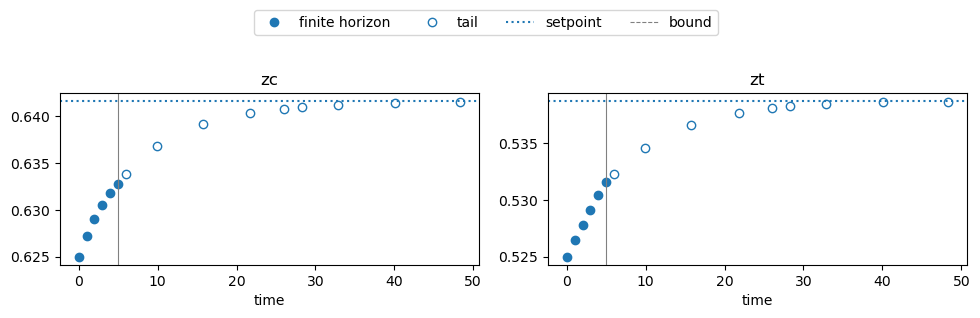

In [3]:
drto.plot_states(m1);

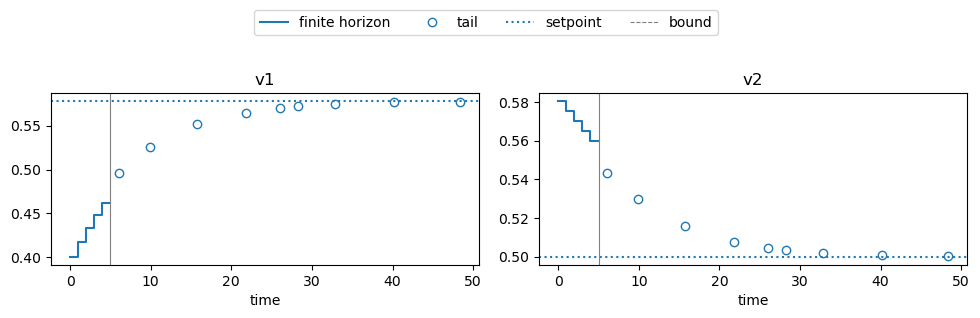

In [4]:
drto.plot_controls(m1);

## Model 2: the finite-horizon baseline (N = 50)

The same statement on fifty sampling steps, with a terminal cost on the
final state and the plain finite-horizon objective. This is the
long-horizon solve the infinite-horizon runs are measured against.


In [5]:
# The baseline reuses the statement. hicks(N2) builds the declared model,
# and this cell adds only the terminal cost and the finite-horizon
# objective.
N2 = 50
m2 = hicks(N2)

tN2 = m2.t.last()
m2.term = Var()

@m2.Constraint()  # the stage cost with the controls removed, at the final time
def term_def(m):
    return m.term == 10*(m.zc[tN2] - m.zc_ss)**2 + 2*(m.zt[tN2] - m.zt_ss)**2

# The objective sums the stage cost over the samples minus the final
# time, which the terminal cost owns. Built before discretization, the
# sum runs over the samples alone.
stage_sum2 = sum(m2.cost[i] for i in sorted(m2.t)[:-1])
m2.obj = Objective(expr=stage_sum2 + m2.term, sense=minimize)

In [6]:
# Discretize, apply the declared profiles, and solve
TransformationFactory("dae.collocation").apply_to(
    m2, wrt=m2.t, nfe=N2, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("drto.parameterize").apply_to(m2)
SolverFactory("ipopt").solve(m2, tee=True);

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     3114
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      906

Total number of variables............................:      755
                     variables with only lower bounds:      151
                variables with lower and upper bounds:      251
                     variables with only upper bounds:        0
Total number of equality constraints.................:      655
Total number

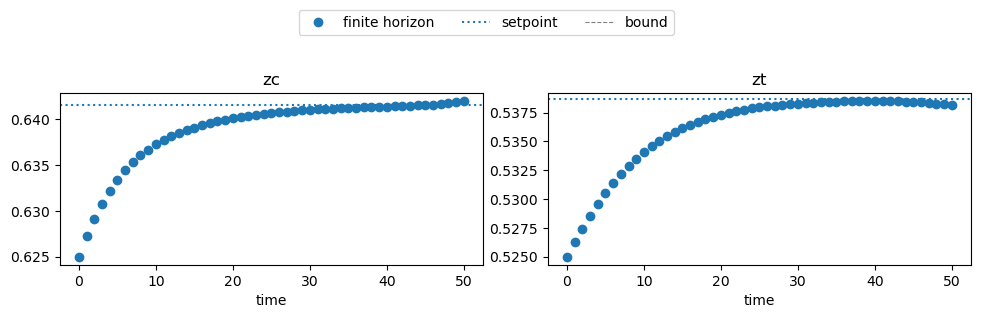

In [7]:
drto.plot_states(m2);

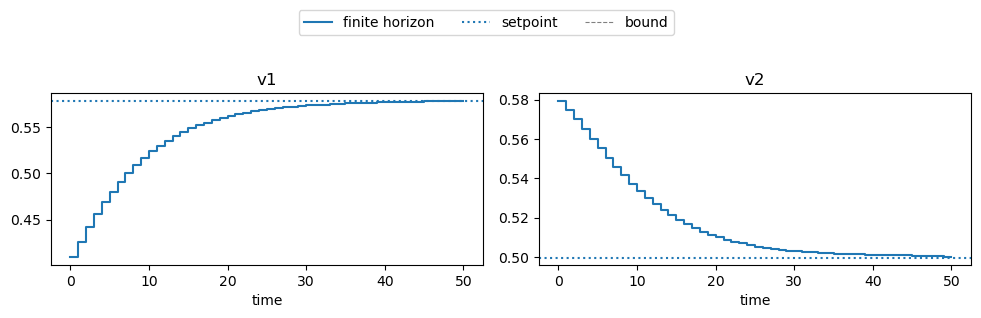

In [8]:
drto.plot_controls(m2);

## Model 3: the segment by hand, with the quadrature state

The construction the transform performs, written out in pyomo.dae on a short
horizon (N = 5): the segment ContinuousSet with the dilated dynamics at
interior Gauss-Legendre points, the linking constraints, the eq. 36 soft
endpoint pin (per state a slack pair and the relaxed equality `z(tau=1) +
eps_up - eps_lo == z_s`, with `mu*(eps_up + eps_lo)` in the objective), and
the tail cost integrated by the quadrature state `phi` (eq. 28), entering the
objective as `beta*phi(1)`. The segment controls carry a pyomo-cvp
`'collocation'` profile, so every copy, boundaries included, is defined by
the element polynomials.

In [9]:
# The finite horizon reuses the statement, and the terminal segment
# (Dinh et al. 2025) is built by hand below.
m3 = hicks(N)

tN = m3.t.last()
m3.tau = ContinuousSet(bounds=(0, 1))   # transformed time tanh(gamma*(t - tN))
m3.gamma = Param(initialize=0.02, mutable=True)  # set from the mesh after discretizing
m3.beta = Param(initialize=1.2)                  # tail-cost safety factor, >= 1

# segment states and controls: same bounds as the finite part. The controls
# are profiles (pyomo-cvp): free values at each element's collocation points,
# every other copy, boundaries included, defined by the element's Lagrange
# polynomial. k = ncp keeps all collocation values free, so this is the
# paper's representation of v(tau) with no extra restriction.
m3.zc_s = Var(m3.tau, bounds=(0, 1), initialize=m3.zc_ss)
m3.zt_s = Var(m3.tau, bounds=(0, None), initialize=m3.zt_ss)
m3.v1_s = Var(m3.tau, bounds=(0.166666666666667, 1), initialize=m3.v1_ss)
m3.v2_s = Var(m3.tau, bounds=(0.025, 1), initialize=m3.v2_ss)
declare_profile(m3.v1_s, m3.v2_s, wrt=m3.tau, profile='collocation')
m3.zc_sdot = DerivativeVar(m3.zc_s, wrt=m3.tau)
m3.zt_sdot = DerivativeVar(m3.zt_s, wrt=m3.tau)

# quadrature state: phi(1) is the tail cost integral from tN to infinity
m3.phi = Var(m3.tau, initialize=0)
m3.phidot = DerivativeVar(m3.phi, wrt=m3.tau)
m3.phi[0].fix(0)

# dilated dynamics (eq. 25) at interior collocation points only: with
# Gauss-Legendre points there is no collocation equation at tau = 0 or 1,
# matching the paper's discretization (eq. 26)
@m3.Constraint(m3.tau)
def seg_dyn_c(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zc_sdot[s] == f_c(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m3.Constraint(m3.tau)
def seg_dyn_t(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zt_sdot[s] == f_t(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

# tail-cost quadrature (eq. 28)
@m3.Constraint(m3.tau)
def seg_quad(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.phidot[s] == psi(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

# stitch the segment onto the end of the finite horizon
@m3.Constraint()
def link_c(m):
    return m.zc_s[0] == m.zc[tN]

@m3.Constraint()
def link_t(m):
    return m.zt_s[0] == m.zt[tN]

# eq. 36 soft endpoint pin: per state a slack pair and the relaxed
# equality z(tau=1) + eps_up - eps_lo == z_s, penalized by mu*(eps_up +
# eps_lo + eps_up**2 + eps_lo**2) in the objective, mirroring
# drto.infinite_horizon's terminal='soft' default: the linear part is
# the exact L1 pin, the quadratic part makes the pin's multipliers
# unique. On states only, so it is order-free relative
# to the control parameterization.
m3.mu = Param(initialize=1000.0, mutable=True)
m3.zc_pin_up = Var(domain=pyo.NonNegativeReals)
m3.zc_pin_lo = Var(domain=pyo.NonNegativeReals)
m3.zt_pin_up = Var(domain=pyo.NonNegativeReals)
m3.zt_pin_lo = Var(domain=pyo.NonNegativeReals)

@m3.Constraint()
def zc_pin_eq(m):
    return m.zc_s[1] + m.zc_pin_up - m.zc_pin_lo == m.zc_ss

@m3.Constraint()
def zt_pin_eq(m):
    return m.zt_s[1] + m.zt_pin_up - m.zt_pin_lo == m.zt_ss

# The objective adds the finite tracking cost, beta times the tail cost,
# and the pin penalty. Built before discretization, the stage sum runs
# over the samples alone.
stage_sum3 = sum(m3.cost[i] for i in sorted(m3.t)[:-1])
m3.obj = Objective(
    expr=stage_sum3 + m3.beta*m3.phi[1]
    + m3.mu*(m3.zc_pin_up + m3.zc_pin_lo + m3.zt_pin_up + m3.zt_pin_lo)
    + m3.mu*(m3.zc_pin_up**2 + m3.zc_pin_lo**2
             + m3.zt_pin_up**2 + m3.zt_pin_lo**2),
    sense=minimize)

In [10]:
# Radau on the finite horizon (as in model 1), Gauss-Legendre on the segment
TransformationFactory("dae.collocation").apply_to(
    m3, wrt=m3.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("dae.collocation").apply_to(
    m3, wrt=m3.tau, nfe=3, ncp=5, scheme="LAGRANGE-LEGENDRE")
TransformationFactory("drto.parameterize").apply_to(m3)  # finite and segment profiles

# gamma rule (paper Fig. 2): put the segment's first collocation point one
# sampling time past tN, so resolution is continuous across the junction
tau11 = sorted(m3.tau)[1]
m3.gamma.set_value(math.atanh(tau11) / h)
SolverFactory("ipopt").solve(m3, tee=True);

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      913
Number of nonzeros in inequality constraint Jacobian.:       40
Number of nonzeros in Lagrangian Hessian.............:      219

Total number of variables............................:      214
                     variables with only lower bounds:       39
                variables with lower and upper bounds:       75
                     variables with only upper bounds:        0
Total number of equality constraints.................:      172
Total number

In [11]:
#Plotting for models 3 and 4
from matplotlib.lines import Line2D

PANEL = (5.0, 3.2)   # panel size (inches), as in drto.plotting
LEGEND_BAND = 0.55   # inches reserved above the panels for the legend

def _draw_panels(panels, tN, t_max, staircase):
    """Draw one fixed-size panel per entry, two columns, clipped to t_max."""
    rows = max(1, math.ceil(len(panels) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(2*PANEL[0], rows*PANEL[1]),
                             sharex=True, squeeze=False)
    flat = [ax for row in axes for ax in row]
    for ax in flat:
        ax.ticklabel_format(useOffset=False)
    for ax in flat[len(panels):]:
        ax.axis("off")
    drew = set()
    for ax, p in zip(flat, panels):
        t, v = p["finite"]
        if staircase:
            pts = [(ti, vi) for ti, vi in zip(t, v + [v[-1]]) if ti <= t_max]
            ax.step(*zip(*pts), where="post", color="C0")
        else:
            pts = [(ti, vi) for ti, vi in zip(t, v) if ti <= t_max]
            ax.plot(*zip(*pts), "o", color="C0")
        for key, marker in (("tail", "o"), ("boundary", "s")):
            t_k, v_k = p.get(key, ((), ()))
            pts = [(ti, vi) for ti, vi in zip(t_k, v_k) if ti <= t_max]
            if pts:
                ax.plot(*zip(*pts), marker, mfc="none", color="C0")
                drew.add(key)
        ax.axhline(p["setpoint"], color="C0", linestyle=":")
        drew.add("setpoint")
        levels = [b for b in p["bounds"] if b is not None]
        if levels:
            lim = ax.get_ylim()  # a distant bound sits outside the window
            for b in levels:
                ax.axhline(b, color="grey", linewidth=0.8, linestyle="--")
            ax.set_ylim(lim)
            drew.add("bound")
        ax.axvline(tN, color="grey", linewidth=0.8)
        ax.set_title(p["title"])
    for ax in flat[max(0, len(panels) - 2):len(panels)]:
        ax.set_xlabel("time")
    handles = [Line2D([], [], color="C0", drawstyle="steps-post") if staircase
               else Line2D([], [], marker="o", color="C0", linestyle="")]
    labels = ["finite horizon"]
    for key, artist, label in (
        ("tail", dict(marker="o", mfc="none", linestyle=""), "tail"),
        ("boundary", dict(marker="s", mfc="none", linestyle=""), "element boundary"),
        ("setpoint", dict(linestyle=":"), "setpoint"),
    ):
        if key in drew:
            handles.append(Line2D([], [], color="C0", **artist))
            labels.append(label)
    if "bound" in drew:
        handles.append(Line2D([], [], color="grey", linewidth=0.8, linestyle="--"))
        labels.append("bound")
    fig.legend(handles, labels, loc="upper center", ncol=len(labels),
               bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout(rect=(0, 0, 1, 1 - LEGEND_BAND / fig.get_figheight()))
    return flat[:len(panels)]

def seg_plot_states(m, tN, t_max=50):
    g = value(m.gamma)
    fe = set(m.tau.get_finite_elements())
    t_fin = m.t.get_finite_elements()
    panels = []
    for z, z_s, ss in ((m.zc, m.zc_s, m.zc_ss), (m.zt, m.zt_s, m.zt_ss)):
        pts = [(tN + math.atanh(s)/g, value(z_s[s]), s in fe)
               for s in sorted(m.tau) if s < 1]
        panels.append(dict(
            title=z.local_name,
            finite=(t_fin, [value(z[i]) for i in t_fin]),
            tail=([p[0] for p in pts if not p[2]],
                  [p[1] for p in pts if not p[2]]),
            boundary=([p[0] for p in pts if p[2]],
                      [p[1] for p in pts if p[2]]),
            setpoint=value(ss),
            bounds=(z[t_fin[0]].lb, z[t_fin[0]].ub),
        ))
    return _draw_panels(panels, tN, t_max, staircase=False)

def seg_plot_controls(m, tN, t_max=50):
    g = value(m.gamma)
    t_fin = m.t.get_finite_elements()
    panels = []
    for v, v_s, ss in ((m.v1, m.v1_s, m.v1_ss), (m.v2, m.v2_s, m.v2_ss)):
        pts = [(tN + math.atanh(s)/g, value(v_s[s]))
               for s in sorted(v_s.index_set()) if s < 1]
        panels.append(dict(
            title=v.local_name,
            finite=(t_fin, [value(v[i]) for i in t_fin[:-1]]),
            tail=([p[0] for p in pts], [p[1] for p in pts]),
            setpoint=value(ss),
            bounds=(getattr(v[t_fin[0]], "lb", None),
                    getattr(v[t_fin[0]], "ub", None)),
        ))
    return _draw_panels(panels, tN, t_max, staircase=True)


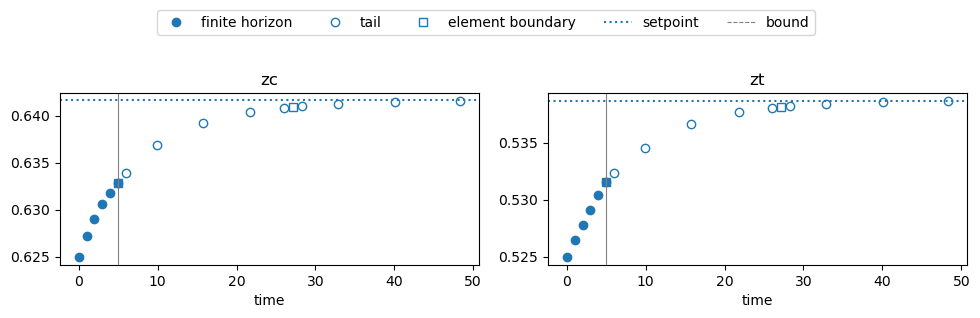

In [12]:
seg_plot_states(m3, tN);

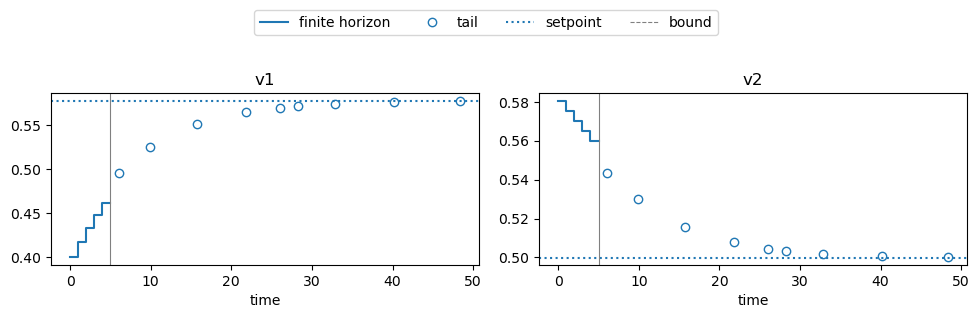

In [13]:
seg_plot_controls(m3, tN);

## Model 4: the weight version, no phi

`phi` is linear bookkeeping: integrating `dphi/dt = psi` by K-point Gauss
collocation is identically K-point Gauss quadrature, so `phi(1)` collapses to
a fixed weighted sum of the stage cost at the segment's collocation points.
Model 4 is model 3 with `phi` deleted and the tail cost written directly into
the objective:

    Phi = beta * sum_{i,k}  h_i * omega_k * psi(z_ik, v_ik) / (gamma*(1 - tau_ik^2))

where `omega_k` are the Gauss-Legendre weights and the `1/(gamma*(1 - tau^2))`
factor is the time-transformation Jacobian, the real-time span each
collocation point represents. The control problem is unchanged: the objective
is still a weighted sum of the one declared stage cost, its index set just
grows by the segment points, with weights supplied by the discretization.
Model 4 carries the same eq. 36 soft endpoint pin as model 3, so it is
exactly the formulation `drto.infinite_horizon` builds: grow
the mesh, grow the dynamics, grow the objective sum, add the relaxed
endpoint pin, after discretization. With the pin in place models 1, 3, and
4 are the same NLP, so they solve to the same objective and the same first
moves to solver tolerance, as the comparison below confirms.

In [14]:
# Model 4 reuses the statement too. hicks(N) gives the finite horizon,
# and the segment of model 3 follows, minus the quadrature state.
m4 = hicks(N)

tN4 = m4.t.last()
m4.tau = ContinuousSet(bounds=(0, 1))
m4.gamma = Param(initialize=0.02, mutable=True)
m4.beta = Param(initialize=1.2)

m4.zc_s = Var(m4.tau, bounds=(0, 1), initialize=m4.zc_ss)
m4.zt_s = Var(m4.tau, bounds=(0, None), initialize=m4.zt_ss)
m4.v1_s = Var(m4.tau, bounds=(0.166666666666667, 1), initialize=m4.v1_ss)
m4.v2_s = Var(m4.tau, bounds=(0.025, 1), initialize=m4.v2_ss)
declare_profile(m4.v1_s, m4.v2_s, wrt=m4.tau, profile='collocation')
m4.zc_sdot = DerivativeVar(m4.zc_s, wrt=m4.tau)
m4.zt_sdot = DerivativeVar(m4.zt_s, wrt=m4.tau)

@m4.Constraint(m4.tau)
def seg_dyn_c(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zc_sdot[s] == f_c(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m4.Constraint(m4.tau)
def seg_dyn_t(m, s):
    if s in m.tau.get_finite_elements():
        return Constraint.Skip
    return m.gamma*(1 - s**2)*m.zt_sdot[s] == f_t(m, m.zc_s[s], m.zt_s[s], m.v1_s[s], m.v2_s[s])

@m4.Constraint()
def link_c(m):
    return m.zc_s[0] == m.zc[tN4]

@m4.Constraint()
def link_t(m):
    return m.zt_s[0] == m.zt[tN4]

# eq. 36 soft endpoint pin, same as model 3: per state a slack pair and
# the relaxed equality z(tau=1) + eps_up - eps_lo == z_s. The
# mu*(eps_up + eps_lo + eps_up**2 + eps_lo**2) penalty folds into the
# objective in the next cell.
m4.mu = Param(initialize=1000.0, mutable=True)
m4.zc_pin_up = Var(domain=pyo.NonNegativeReals)
m4.zc_pin_lo = Var(domain=pyo.NonNegativeReals)
m4.zt_pin_up = Var(domain=pyo.NonNegativeReals)
m4.zt_pin_lo = Var(domain=pyo.NonNegativeReals)

@m4.Constraint()
def zc_pin_eq(m):
    return m.zc_s[1] + m.zc_pin_up - m.zc_pin_lo == m.zc_ss

@m4.Constraint()
def zt_pin_eq(m):
    return m.zt_s[1] + m.zt_pin_up - m.zt_pin_lo == m.zt_ss

# no quadrature state: the tail cost enters the objective directly, with
# explicit weights, after discretization (next cell)


In [15]:
TransformationFactory("dae.collocation").apply_to(
    m4, wrt=m4.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("dae.collocation").apply_to(
    m4, wrt=m4.tau, nfe=3, ncp=5, scheme="LAGRANGE-LEGENDRE")
TransformationFactory("drto.parameterize").apply_to(m4)

m4.gamma.set_value(math.atanh(sorted(m4.tau)[1]) / h)

# tail cost as explicit Gauss weights: phi(1), eliminated. omega_k are
# the 5-point Gauss-Legendre weights on [0, 1]. The interior points of
# each segment element are exactly the corresponding nodes.
_, omega = np.polynomial.legendre.leggauss(5)
omega = omega / 2
fe = m4.tau.get_finite_elements()
pts = sorted(m4.tau)
tail4 = 0
for iel in range(len(fe) - 1):
    h_i = fe[iel+1] - fe[iel]
    interior = [p for p in pts if fe[iel] < p < fe[iel+1]]
    for p, w in zip(interior, omega):
        tail4 = tail4 + h_i * w * psi(m4, m4.zc_s[p], m4.zt_s[p],
                                      m4.v1_s[p], m4.v2_s[p]) / (m4.gamma*(1 - p**2))

# The stage sum runs over the sample grid, which discretization left in
# place as the element boundaries.
stage_sum4 = sum(m4.cost[i] for i in m4.t.get_finite_elements()[:-1])
m4.obj = Objective(
    expr=stage_sum4 + m4.beta*tail4
    + m4.mu*(m4.zc_pin_up + m4.zc_pin_lo + m4.zt_pin_up + m4.zt_pin_lo)
    + m4.mu*(m4.zc_pin_up**2 + m4.zc_pin_lo**2
             + m4.zt_pin_up**2 + m4.zt_pin_lo**2),
    sense=minimize)

SolverFactory("ipopt").solve(m4, tee=True);

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      718
Number of nonzeros in inequality constraint Jacobian.:       40
Number of nonzeros in Lagrangian Hessian.............:      219

Total number of variables............................:      181
                     variables with only lower bounds:       39
                variables with lower and upper bounds:       75
                     variables with only upper bounds:        0
Total number of equality constraints.................:      139
Total number

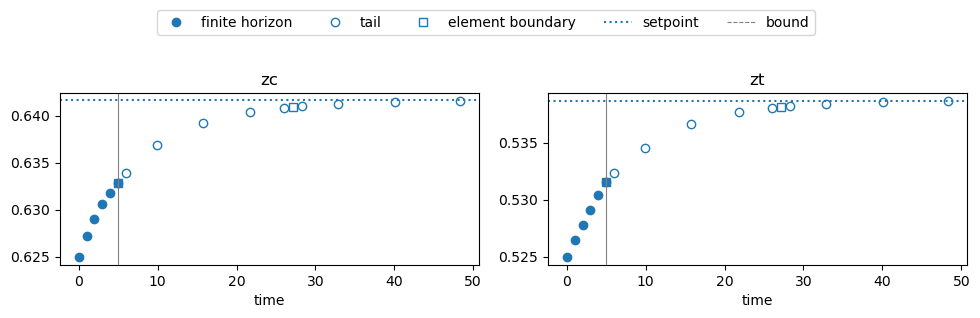

In [16]:
seg_plot_states(m4, tN4);

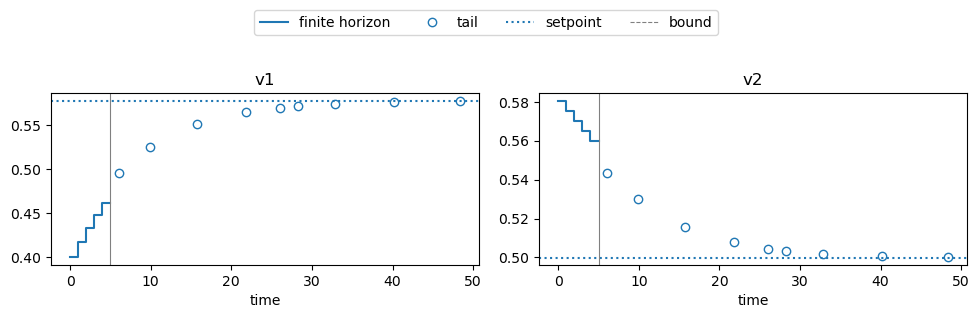

In [17]:
seg_plot_controls(m4, tN4);

In [18]:
# Validation by equivalence: with the eq. 36 soft pin on models 3 and 4, all
# three are the same NLP under the default settings, so they solve to the same
# objective and the same first moves, to solver tolerance.
m1_obj = value(next(m1.component_data_objects(pyo.Objective, active=True)))
print(f"objective : m1 = {m1_obj:.9f}   m3 = {value(m3.obj):.9f}   m4 = {value(m4.obj):.9f}")
print(f"first v1  : m1 = {value(m1.v1[0]):.6f}   m3 = {value(m3.v1[0]):.6f}   m4 = {value(m4.v1[0]):.6f}")
print(f"first v2  : m1 = {value(m1.v2[0]):.6f}   m3 = {value(m3.v2[0]):.6f}   m4 = {value(m4.v2[0]):.6f}")

# the L1 penalty is exact: the endpoint lands on the setpoint and the slacks vanish
seg1 = m1.drto_ih
print(f"endpoint slacks (m1): "
      f"zc {value(seg1.zc_pin_up) + value(seg1.zc_pin_lo):.2e}, "
      f"zt {value(seg1.zt_pin_up) + value(seg1.zt_pin_lo):.2e}")

tol = 1e-5
for mk in (m3, m4):
    assert abs(value(mk.obj) - m1_obj) < tol, "objective mismatch"
    assert abs(value(mk.v1[0]) - value(m1.v1[0])) < tol, "first v1 mismatch"
    assert abs(value(mk.v2[0]) - value(m1.v2[0])) < tol, "first v2 mismatch"
print(f"models 1, 3, 4 agree to within {tol:g}")

objective : m1 = 0.186443353   m3 = 0.186443193   m4 = 0.186443201
first v1  : m1 = 0.400378   m3 = 0.400378   m4 = 0.400378
first v2  : m1 = 0.580429   m3 = 0.580429   m4 = 0.580429
endpoint slacks (m1): zc -1.99e-08, zt -1.99e-08
models 1, 3, 4 agree to within 1e-05
